In [37]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

In [39]:
df = pd.read_csv("/content/gdrive/MyDrive/Praktikum_ML/Praktikum04/Data/calonpembelimobil.csv")
print(df.head())

   ID  Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Beli_Mobil
0   1    32       1        0               0          240           1
1   2    49       2        1               1          100           0
2   3    52       1        0               2          250           1
3   4    26       2        1               1          130           0
4   5    45       3        0               2          237           1


In [40]:
X = df.drop(['ID', 'Beli_Mobil'], axis=1)
y = df['Beli_Mobil']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
categorical_features = ['Status', 'Kelamin', 'Memiliki_Mobil']
numerical_features = ['Usia', 'Penghasilan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Usia', 'Penghasilan']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Status', 'Kelamin',
                                                   'Memiliki_Mobil'])])),
                ('classifier', LogisticRegression())])

In [43]:
y_pred = model.predict(X_test)

Accuracy: 0.9250
Precision: 0.9481
Recall: 0.9412
F1-score: 0.9446
ROC AUC Score: 0.9159


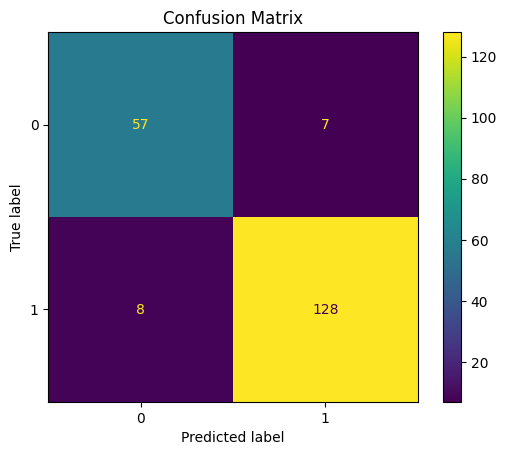

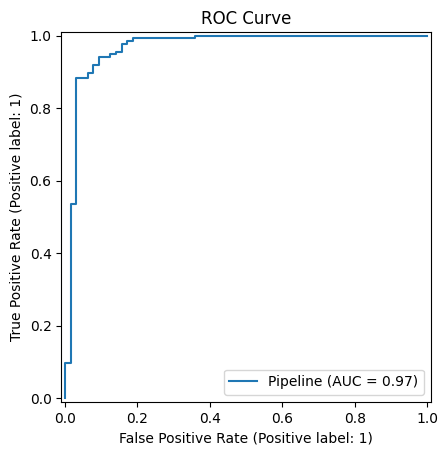

In [44]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

In [52]:
# Ganti bagian ini dengan data baru Anda untuk prediksi
data_baru_anda = pd.DataFrame({
    "Usia": [35],
    "Penghasilan": [75000],
    "Status": [2], # Sesuaikan dengan kode status yang valid dari data pelatihan mobil
    "Kelamin": [1], # Sesuaikan dengan kode kelamin yang valid dari data pelatihan mobil
    "Memiliki_Mobil": [0] # Sesuaikan dengan kode memiliki mobil yang valid dari data pelatihan mobil
})

# --- Pastikan data pelatihan dan model yang benar (untuk data mobil) digunakan ---
# Muat ulang data pembeli mobil dan bagi kembali data pelatihan/pengujian
# Ini untuk memastikan X_train dan y_train berisi data pembeli mobil yang benar
try:
    df_car_buyer = pd.read_csv("/content/gdrive/MyDrive/Praktikum_ML/Praktikum04/Data/calonpembelimobil.csv")
    X_car_buyer = df_car_buyer.drop(['ID', 'Beli_Mobil'], axis=1)
    y_car_buyer = df_car_buyer['Beli_Mobil']
    X_train_car_buyer, X_test_car_buyer, y_train_car_buyer, y_test_car_buyer = train_test_split(X_car_buyer, y_car_buyer, test_size=0.2, random_state=42)
    print("Data pembeli mobil berhasil dimuat dan dibagi kembali.")

except FileNotFoundError:
    print("Error: File 'calonpembelimobil.csv' tidak ditemukan. Mohon periksa path file.")
    # Exit or handle the error appropriately if data cannot be loaded
    exit() # Or raise an exception, or return

# Redefinisikan preprocessor untuk data mobil
categorical_features = ['Status', 'Kelamin', 'Memiliki_Mobil']
numerical_features = ['Usia', 'Penghasilan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Redefinisikan dan latih ulang model pipeline dengan preprocessor yang benar
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Latih ulang model menggunakan data pelatihan mobil yang baru dimuat
model.fit(X_train_car_buyer, y_train_car_buyer)
print("Model pembeli mobil berhasil dilatih ulang.")
# --- Akhir dari bagian memastikan data pelatihan dan model yang benar ---


try:
    # Preprocess data baru menggunakan preprocessor yang sudah dilatih dari model
    data_baru_anda_processed = model.named_steps['preprocessor'].transform(data_baru_anda)

    # Buat prediksi menggunakan model yang sudah dilatih
    prediksi_data_baru = model.predict(data_baru_anda_processed)

    print("\nHasil prediksi untuk data baru Anda:")
    # Tampilkan prediksi
    print("Prediksi:", "Membeli Mobil" if prediksi_data_baru[0]==1 else "Tidak Membeli Mobil")

    # Jika Anda memiliki banyak baris data baru, Anda bisa menampilkan semua prediksi
    # print("Prediksi:", ["Membeli Mobil" if p==1 else "Tidak Membeli Mobil" for p in prediksi_data_baru])

except ValueError as e:
    print("Pastikan data baru memiliki kolom yang benar dan tipe data yang sesuai dengan data pelatihan.")
except KeyError as e:
     print("Pastikan nama langkah pipeline 'preprocessor' sudah benar.")
except Exception as e:
    print(f"Terjadi kesalahan yang tidak terduga: {e}")

Data pembeli mobil berhasil dimuat dan dibagi kembali.
Model pembeli mobil berhasil dilatih ulang.
Pastikan data baru memiliki kolom yang benar dan tipe data yang sesuai dengan data pelatihan.


In [49]:
print("Matriks Konfusi:")
print("--------------")
print(f"{'':<20} | {'Diprediksi Tidak Membeli':<25} | {'Diprediksi Membeli':<20}")
print(f"{'-'*20}-|-{'-'*25}-|-{'-'*20}")
print(f"{'Aktual Tidak Membeli':<20} | {cm[0, 0]:<25} | {cm[0, 1]:<20}")
print(f"{'Aktual Membeli':<20} | {cm[1, 0]:<25} | {cm[1, 1]:<20}")
print("--------------")

Matriks Konfusi:
--------------
                     | Diprediksi Tidak Membeli  | Diprediksi Membeli  
---------------------|---------------------------|---------------------
Aktual Tidak Membeli | 57                        | 7                   
Aktual Membeli       | 8                         | 128                 
--------------
